<a href="https://colab.research.google.com/github/rajshre311-alt/rajeshree_report-amb2199-/blob/main/paddycode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   Min temp_D91_D120  Max temp_D91_D120  Relative Humidity_D91_D120  \
0               16.0               33.0                          85   
1               16.0               30.5                          87   
2               18.0               33.0                          79   
3               15.5               32.5                          84   
4               16.5               35.0                          81   

   Paddy yield(in Kg)  
0               35028  
1               35412  
2               36300  
3               35016  
4               34044  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Min temp_D91_D120           74 non-null     float64
 1   Max temp_D91_D120           74 non-null     float64
 2   Relative Humidity_D91_D120  74 non-null     int64  
 3   Paddy yi

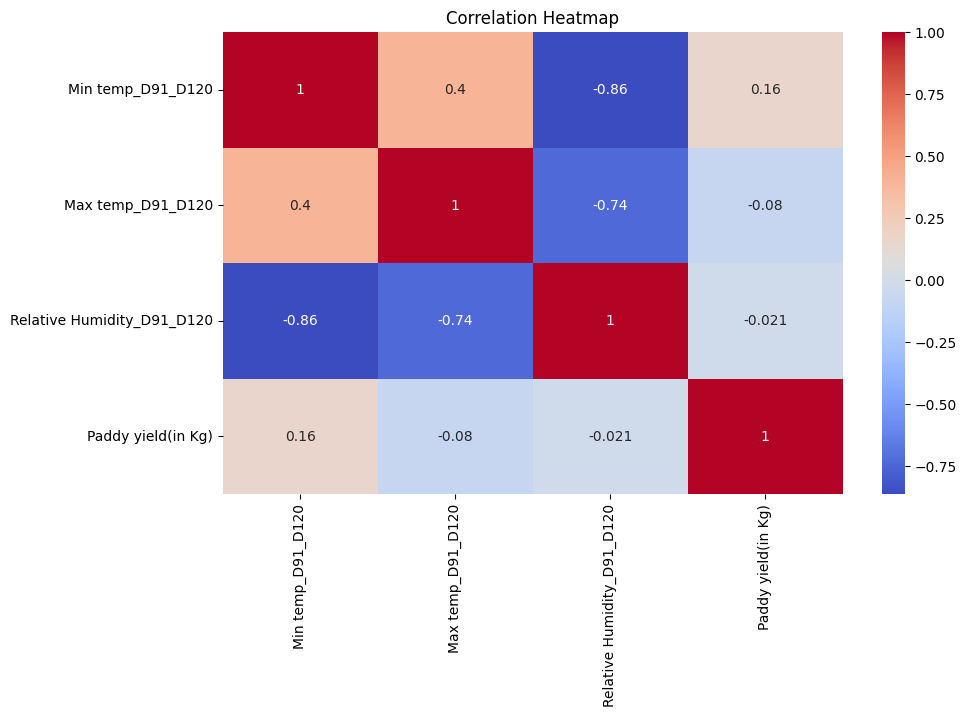

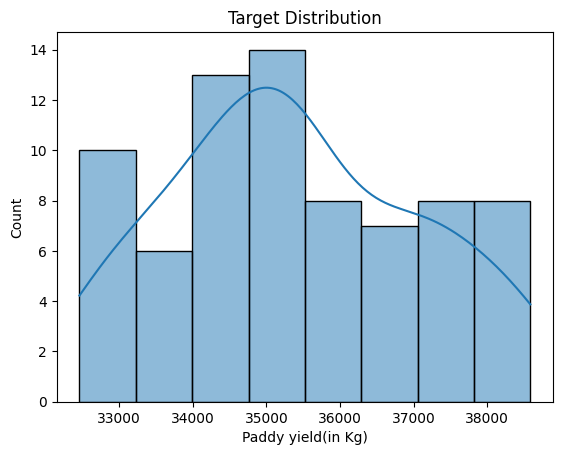

Best Decision Tree Params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Random Forest Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Ridge Params: {'alpha': 1}

Tuned Model Performance:
                 Model           MSE          MAE  R2 Score
0  Tuned Decision Tree  2.346195e+06  1270.546667 -0.024487
1  Tuned Random Forest  2.293930e+06  1243.192891 -0.001665
2          Tuned Ridge  2.830648e+06  1445.142817 -0.236028

Model Performance:
               Model           MSE          MAE  R2 Score
0  Linear Regression  2.827162e+06  1465.659466 -0.234505
1      Decision Tree  2.319267e+06  1255.093333 -0.012728
2      Random Forest  2.246119e+06  1227.609180  0.019212


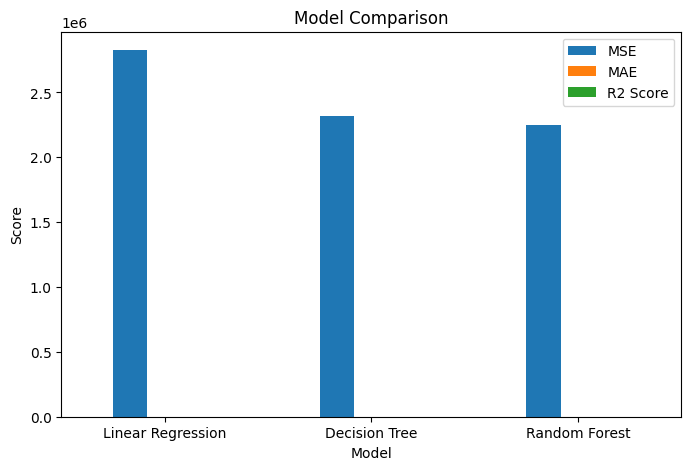


Best Model: Random Forest


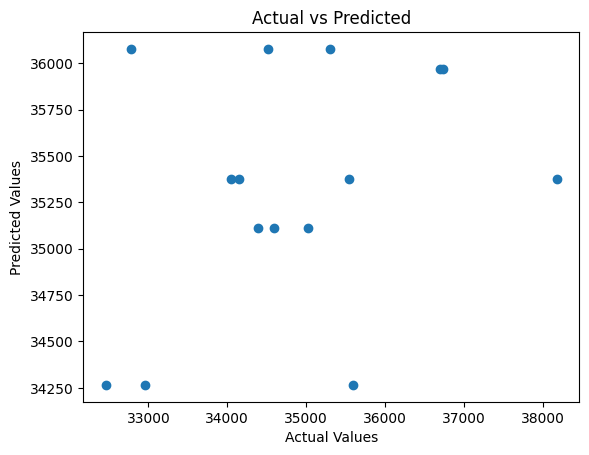

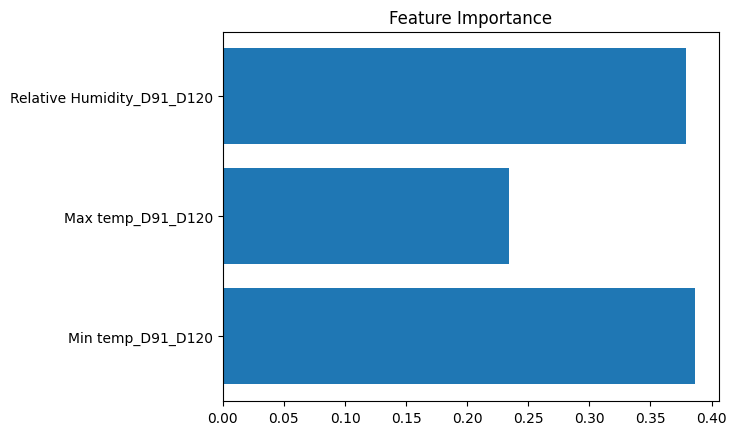

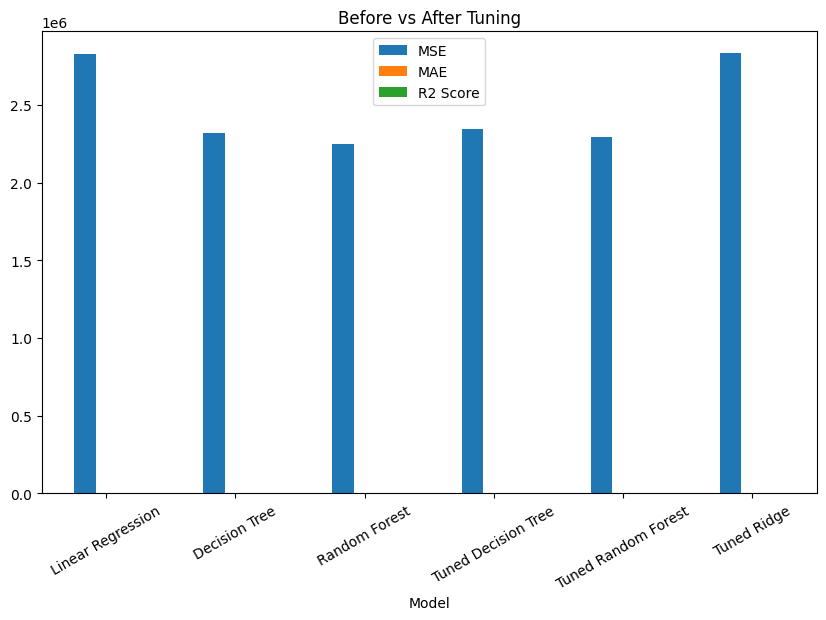

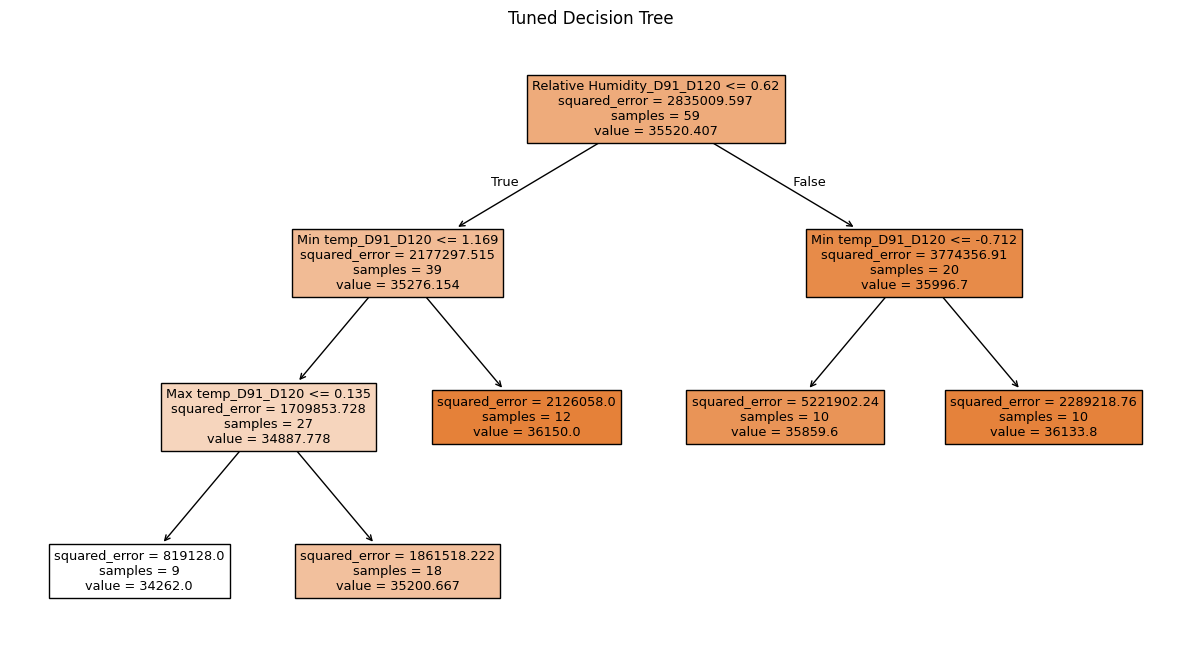

In [ ]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv("/content/cleaned_dataset_v2.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# 3. DATA PREPROCESSING
# ==========================================

# Drop rows with missing values (if any)
df = df.dropna()

# Separate features and target
# 👉 CHANGE TARGET COLUMN NAME if needed
target_column = df.columns[-1]   # last column as target

X = df.drop(columns=[target_column])
y = df[target_column]

# Convert categorical to numeric (if any)
X = pd.get_dummies(X)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==========================================
# 4. DATA VISUALIZATION
# ==========================================

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Histogram of target
plt.figure()
sns.histplot(y, kde=True)
plt.title("Target Distribution")
plt.show()

# Pairplot (optional - may be heavy)
# sns.pairplot(df)
# plt.show()

# ==========================================
# 5. TRAIN MODELS
# ==========================================

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, mae, r2])
# ==========================================
# 12. HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import GridSearchCV

# ------------------------------------------
# 🔹 1. Decision Tree Tuning
# ------------------------------------------
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
print("Best Decision Tree Params:", dt_grid.best_params_)

# ------------------------------------------
# 🔹 2. Random Forest Tuning
# ------------------------------------------
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best Random Forest Params:", rf_grid.best_params_)

# ------------------------------------------
# 🔹 3. Linear Model Tuning (Ridge Regression)
# ------------------------------------------
from sklearn.linear_model import Ridge

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
print("Best Ridge Params:", ridge_grid.best_params_)
# ==========================================
# 13. EVALUATE TUNED MODELS
# ==========================================

tuned_models = {
    "Tuned Decision Tree": best_dt,
    "Tuned Random Forest": best_rf,
    "Tuned Ridge": best_ridge
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    tuned_results.append([name, mse, mae, r2])

tuned_df = pd.DataFrame(tuned_results, columns=["Model", "MSE", "MAE", "R2 Score"])

print("\nTuned Model Performance:")
print(tuned_df)


# ==========================================
# 6. ERROR TABLE
# ==========================================

results_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "R2 Score"])
print("\nModel Performance:")
print(results_df)

# ==========================================
# 7. MODEL COMPARISON GRAPH
# ==========================================

results_df.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# ==========================================
# 8. BEST MODEL SELECTION
# ==========================================

best_model_name = results_df.loc[results_df["R2 Score"].idxmax(), "Model"]
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# ==========================================
# 9. PREDICTION GRAPH (ACTUAL vs PREDICTED)
# ==========================================

y_pred_best = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# ==========================================
# 10. DECISION TREE VISUALIZATION
# ==========================================

if best_model_name == "Decision Tree":
    plt.figure(figsize=(15,8))
    plot_tree(best_model, filled=True, feature_names=X.columns)
    plt.title("Decision Tree Structure")
    plt.show()

# ==========================================
# 11. FEATURE IMPORTANCE (for RF/DT)
# ==========================================

if best_model_name in ["Random Forest", "Decision Tree"]:
    importance = best_model.feature_importances_
    feature_names = X.columns

    plt.figure()
    plt.barh(feature_names, importance)
    plt.title("Feature Importance")
    plt.show()

 # Combine old + tuned results
final_results = pd.concat([results_df, tuned_df])

final_results.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Before vs After Tuning")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(15,8))
plot_tree(best_dt, filled=True, feature_names=X.columns)
plt.title("Tuned Decision Tree")
plt.show()